In [12]:
!pip install plotly
!pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\Tanmay\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\Tanmay\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import plotly.express as px
import seaborn as sns

## load data

In [6]:
base_path = "transformed_data/"

customers = pd.read_excel(base_path + "customers_transformed.xlsx")
orders = pd.read_excel(base_path + "orders_transformed.xlsx")
order_items = pd.read_excel(base_path + "order_items_transformed.xlsx")
products = pd.read_excel(base_path + "products_transformed.xlsx")
sellers = pd.read_excel(base_path + "sellers_transformed.xlsx")
payments = pd.read_excel(base_path + "payments_transformed.xlsx")
reviews = pd.read_excel(base_path + "reviews_transformed.xlsx")
geolocation = pd.read_excel(base_path + "geolocation_transformed.xlsx")

In [9]:
orders.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
purchase_month                              str
purchase_quarter                          int64
purchase_weekday                            str
delivery_delay                            int64
processing_time                           int64
dtype: object

## 1.Monthly Revenue Trend

In [20]:
sales = orders.merge(order_items, on="order_id")       # merge data

sales["order_purchase_timestamp"] = pd.to_datetime(sales["order_purchase_timestamp"])       # convert date

monthly = sales.groupby(
    sales["order_purchase_timestamp"].dt.to_period("M")
)["price"].sum()                                            # create monthly revenue

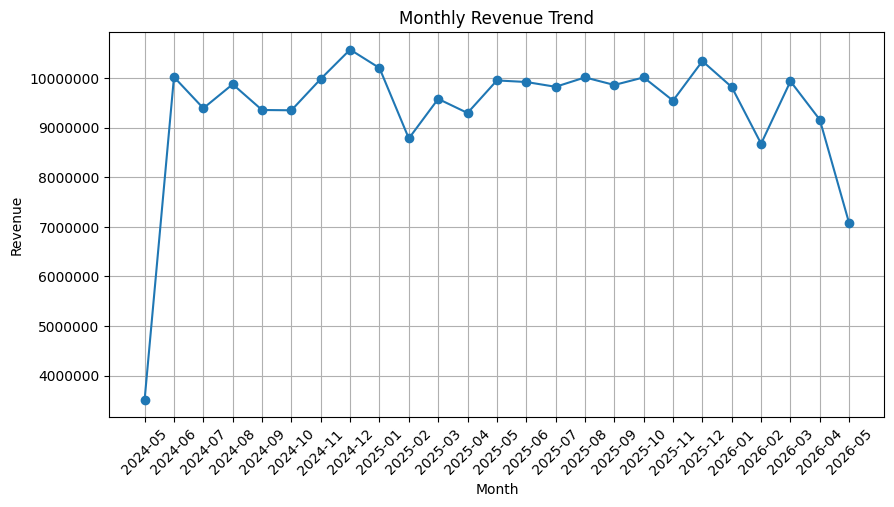

In [24]:
monthly.index = monthly.index.astype(str)

plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly.values, marker="o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.ticklabel_format(style='plain', axis='y')

plt.grid()
plt.show()

## 2.Top Selling Products

In [25]:
top_products = order_items.groupby("product_id")["order_id"].count().reset_index()
top_products.columns = ["product_id", "total_sales"]                                      # count product sales

top_products = top_products.sort_values(by="total_sales", ascending=False).head(10)        # sort and take top 10

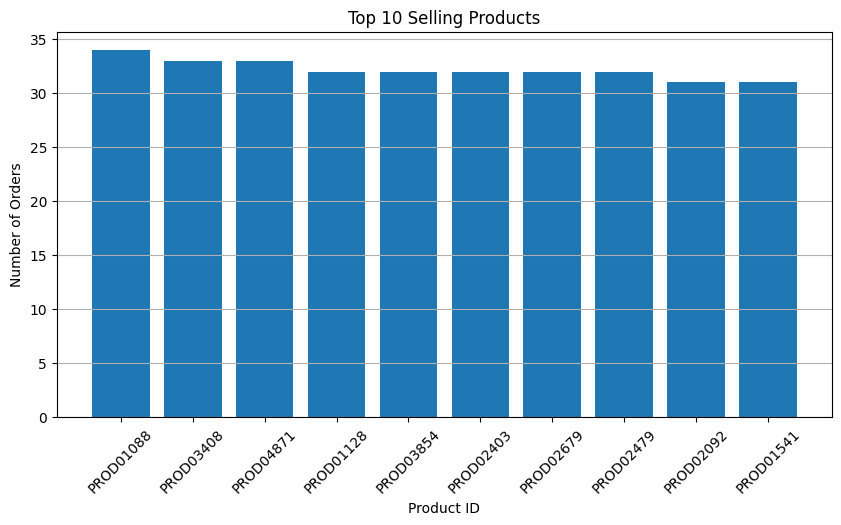

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(top_products["product_id"], top_products["total_sales"])

plt.title("Top 10 Selling Products")
plt.xlabel("Product ID")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

## 3.Top Revenue Categories

In [29]:
cat_data = order_items.merge(products, on="product_id")               #merge products with order items

category_revenue = cat_data.groupby("product_category_name")["price"].sum().reset_index()        # group by category and calculate revenue

category_revenue = category_revenue.sort_values(by="price", ascending=False).head(10)           # take top 10 categories

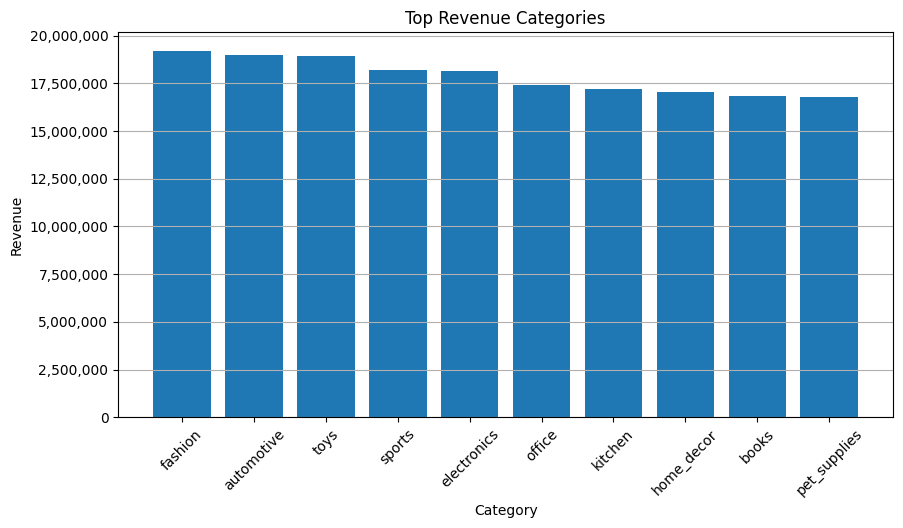

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(category_revenue["product_category_name"], category_revenue["price"])

plt.title("Top Revenue Categories")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45)
plt.grid(axis="y")

plt.show()

## 4.Top States by Revenue

In [34]:
state_rev = orders.merge(customers, on="customer_id")
state_rev = state_rev.merge(order_items, on="order_id")      # merge tables

state_rev = state_rev.groupby("customer_state")["price"].sum().reset_index()        # Calculate state-wise revenue

state_rev = state_rev.sort_values(by="price", ascending=False).head(10)        # Take top 10 states

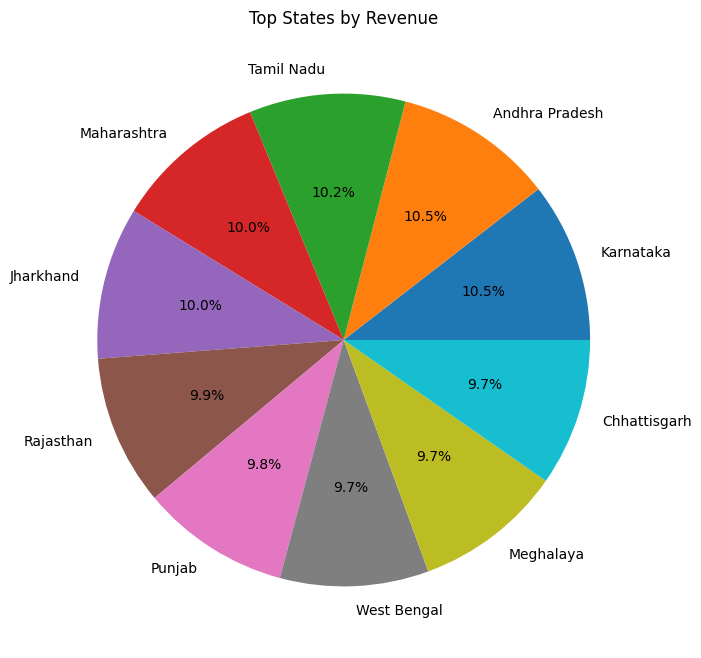

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    state_rev["price"],
    labels=state_rev["customer_state"],
    autopct="%1.1f%%"
)

plt.title("Top States by Revenue")

plt.show()

## 5.Delivery Delay Analysis

In [36]:
orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)
orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)                                                                # Convert columns into datetime

orders["delivery_delay"] = (
    orders["order_delivered_customer_date"]
    - orders["order_estimated_delivery_date"]
).dt.days                                                        # calculate delivery delay

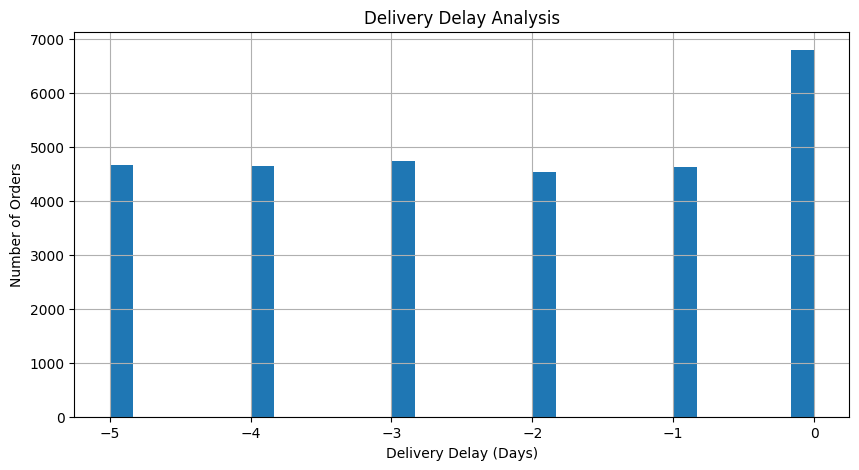

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(orders["delivery_delay"].dropna(), bins=30)

plt.title("Delivery Delay Analysis")
plt.xlabel("Delivery Delay (Days)")
plt.ylabel("Number of Orders")

plt.grid()

plt.show()

## 6.Payment Method Analysis

In [38]:
payment_analysis = payments.groupby("payment_type")["payment_value"].sum().reset_index()                 # group payment data

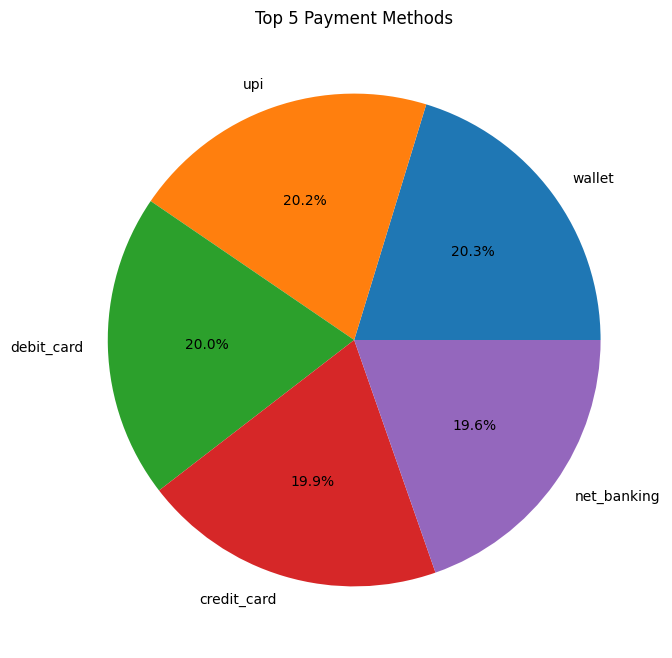

In [42]:
import matplotlib.pyplot as plt

top5 = payment_analysis.sort_values(
    by="payment_value",
    ascending=False
).head(5)

plt.figure(figsize=(8,8))

plt.pie(
    top5["payment_value"],
    labels=top5["payment_type"],
    autopct="%1.1f%%"
)

plt.title("Top 5 Payment Methods")

plt.show()

## 7.Correlation analysis heatmap

In [43]:
corr_data = order_items[
    ["price", "freight_value", "total_item_value"]
].corr()                                                # create correlation matrix

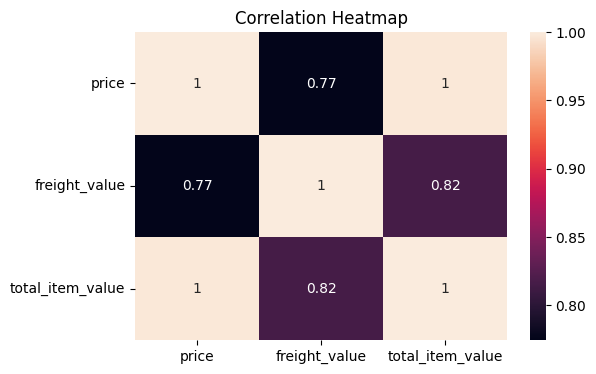

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_data,
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

## 8.Highest rated products

In [47]:
top_rated = reviews.merge(
    order_items,
    on="order_id"
)                                  # Merge reviews and order items

top_rated = top_rated.groupby(
    "product_id"
)["review_score"].mean().reset_index()         # Calculate average rating per product

top_rated = top_rated.sort_values(
    by="review_score",
    ascending=False
).head(10)                                 # Select top 10 products

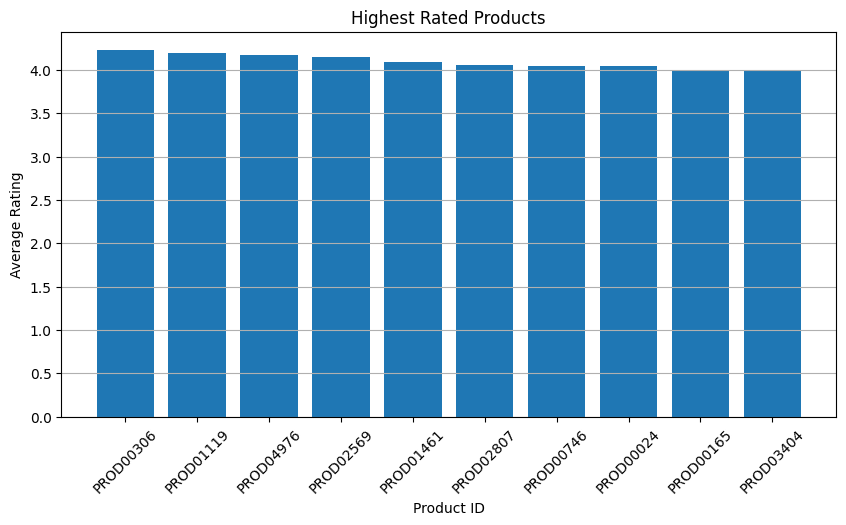

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    top_rated["product_id"],
    top_rated["review_score"]
)

plt.title("Highest Rated Products")
plt.xlabel("Product ID")
plt.ylabel("Average Rating")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.show()